## Task 4c - Euler and Heun methods on different step lengths

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def ode(t, z):
    z1, z2 = z
    return np.array([z2, -9.81 * np.sin(z1)])


In [26]:
def euler(zn, tn,  h, ode):
    return zn + h * ode(tn, zn)


def heun(zn, tn, tn_next, h, ode):
    k1 = euler(zn, tn, h, ode)
    return zn + (h/2) * (ode(tn, zn) + ode(tn_next, k1))



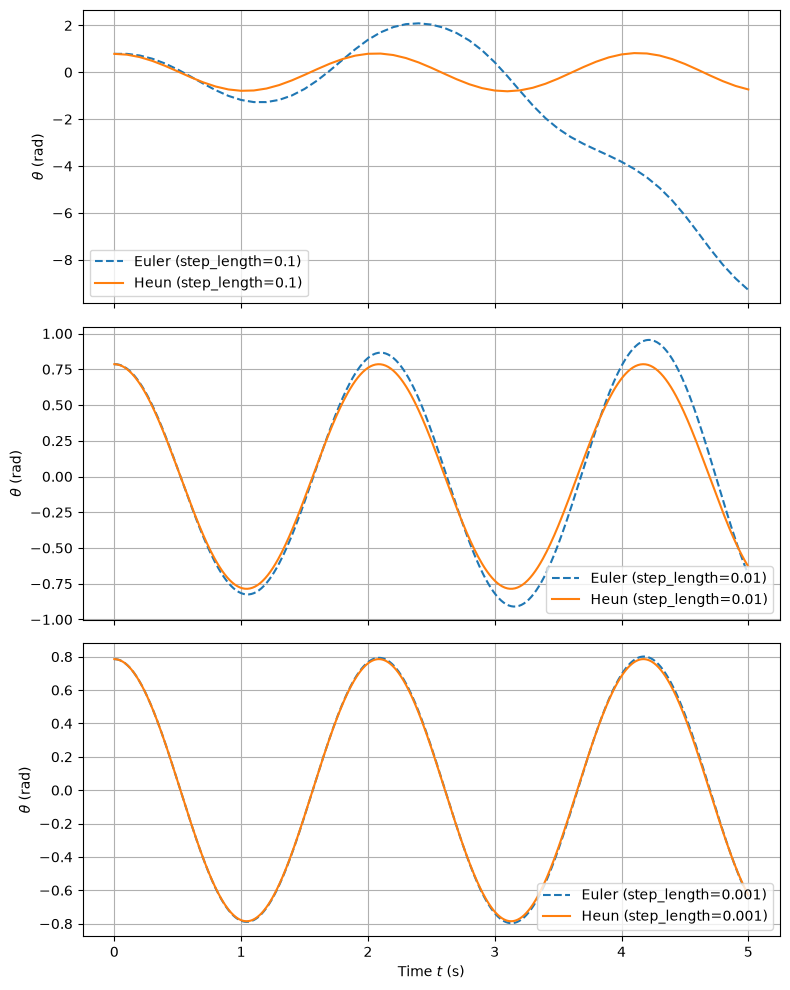

In [27]:
euler_num_vals = {}
heun_num_vals = {}
step_lengths = [0.1, 0.01, 0.001]
z1_0 = np.pi/4
z2_0 = 0
iv = np.array([z1_0, z2_0])

for step_length in step_lengths:
    euler_step_num_vals = []
    heun_step_num_vals = []
    
    N = int(5 / step_length)
    z_euler = iv.copy()
    z_heun = iv.copy()
    t = 0.0
    t_next = 0.0
    
    euler_step_num_vals.append(iv.copy())
    heun_step_num_vals.append(iv.copy())
    for i in range(N):
        z_euler = euler(z_euler, t, step_length, ode)
        euler_step_num_vals.append(z_euler)
    
        t_next = t + step_length
        z_heun = heun(z_heun, t, t_next, step_length, ode)
        heun_step_num_vals.append(z_heun)
        t = t_next
   
    euler_num_vals[step_length] = np.array(euler_step_num_vals)
    heun_num_vals[step_length] = np.array(heun_step_num_vals)
    



fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)
for i, step_length in enumerate(step_lengths):
    t_vals = np.linspace(0, 5, len(euler_num_vals[step_length]))
    axes[i].plot(t_vals, euler_num_vals[step_length][:, 0], label=f"Euler (step_length={step_length})", linestyle="--")
    axes[i].plot(t_vals, heun_num_vals[step_length][:, 0], label=f"Heun (step_length={step_length})")

    axes[i].set_ylabel(r"$\theta$ (rad)")
    axes[i].legend()
    axes[i].grid(True)
        
axes[-1].set_xlabel(r"Time $t$ (s)")
plt.tight_layout()
plt.show()


        

## Task 4 d - Energy conservation

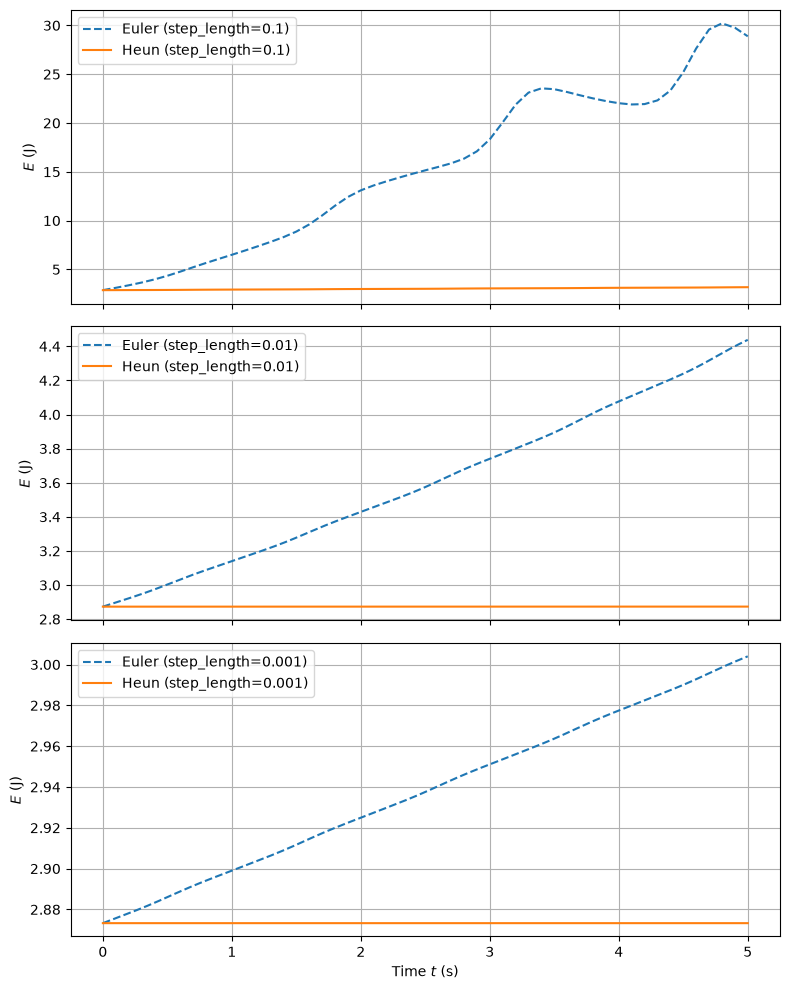

In [28]:
def energy_formula(L, z):
    z1, z2 = z
    return 1/2 * L**2 * z2** 2 + 9.81 * L * (1 - np.cos(z1))

def compute_energy(z):
    z1, z2 = z[:,0],z[:,1] 
    E_0 = energy_formula(L=1, z=[z1, z2])
    return E_0




fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)
for i, step_length in enumerate(step_lengths):
    t_vals = np.linspace(0, 5, len(euler_num_vals[step_length]))
    E_euler = compute_energy(euler_num_vals[step_length])
    E_heun = compute_energy(heun_num_vals[step_length])
    axes[i].plot(t_vals, E_euler, label=f"Euler (step_length={step_length})", linestyle="--")
    axes[i].plot(t_vals, E_heun, label=f"Heun (step_length={step_length})")

    axes[i].set_ylabel(r"$E$ (J)")    
    axes[i].legend()
    axes[i].grid(True)
    
axes[-1].set_xlabel(r"Time $t$ (s)")
plt.tight_layout()
plt.show()
